## Deducción de la Función de Transferencia $H(s)$

> **Nota:** Debido a que el nodo de entrada $PA$ está conectado directamente al nodo $V_L$ mediante un conductor ideal, ambos voltajes son equivalentes ($V_L = PA$ y $V_L(s) = PA(s)$).

### 1. Impedancia del Primer Bloque ($Z_1$)
Corresponde al arreglo en paralelo de la resistencia $R_c$ y el inductor $L$:

$$Z_1(s) = R_c \parallel sL = \frac{R_c \cdot sL}{R_c + sL}$$

### 2. Impedancia del Segundo Bloque ($Z_2$)
Corresponde al arreglo en paralelo del capacitor $C$ y la resistencia de carga $R_p$:

$$Z_2(s) = R_p \parallel \frac{1}{sC} = \frac{R_p \cdot \frac{1}{sC}}{R_p + \frac{1}{sC}} = \frac{R_p}{1 + s C R_p}$$

### 3. Impedancia Total del Circuito ($Z_{\text{total}}$)
Como ambos bloques están conectados en serie, la impedancia equivalente vista desde la entrada es la suma de $Z_1(s)$ y $Z_2(s)$:

$$Z_{\text{total}}(s) = Z_1(s) + Z_2(s) = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

---

### 4. Ecuación para el Voltaje $V_L$ ($PA$)
Aplicando la Ley de Ohm generalizada en el dominio de Laplace, el voltaje $V_L(s)$ (equivalente a $PA(s)$) en función del flujo de entrada $Q(s)$ es:

$$V_L(s) = PA(s) = Q(s) \cdot Z_{\text{total}}(s) = Q(s) \left( \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p} \right)$$

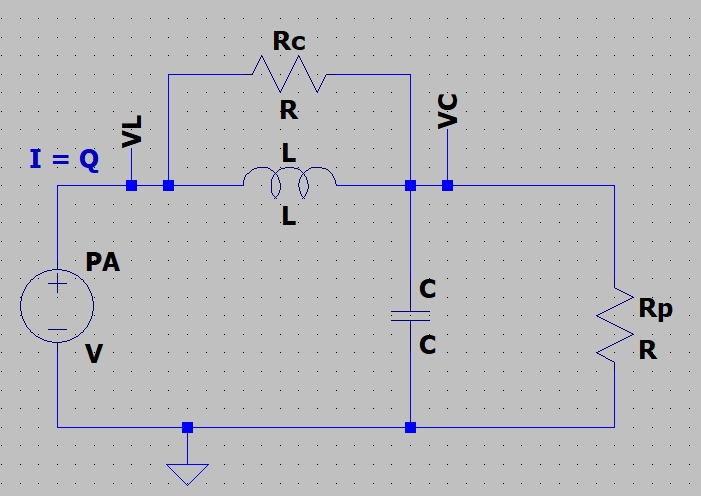
---

### 5. Función de Transferencia $H(s)$
La función de transferencia $H(s)$ se define como la relación entre la respuesta de voltaje $V_L(s)$ ($PA(s)$) y la entrada de corriente $Q(s)$:

$$H(s) = \frac{V_L(s)}{Q(s)} = \frac{PA(s)}{Q(s)} = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

Se agrupan los términos en una sola fracción:

$$H(s) = \frac{(R_c R_p L C) \, s^2 + (R_c L + R_p L) \, s + R_c R_p}{(R_p L C) \, s^2 + (R_c R_p C + L) \, s + R_c}$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.signal as signal

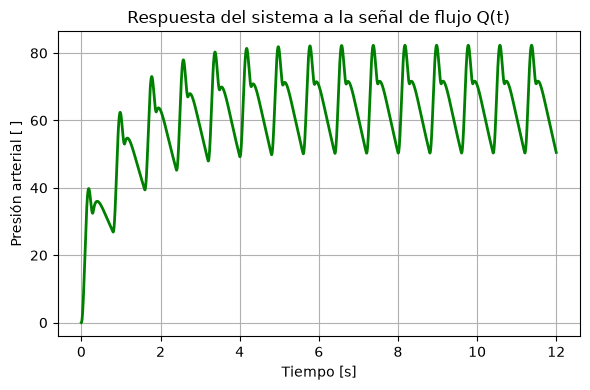

In [3]:
# Parámetros
Q_max = 500.0  # Flujo máximo
Ts = 0.3       # Tiempo de sístole [segundos]
Td = 0.5       # Tiempo de diástole [segundos]
T = Ts + Td    # Periodo total de un ciclo cardíaco (0.8 s ≈ 75 bpm)
Rc = 0.055       # Resistencia de la arteria
Rp = 0.7       # Resistencia periférica
L = 0.005       # Inductancia
C = 1.5       # Capacitancia



numerador=[(Rc*Rp*L*C),(Rc*L+Rp*L), (Rc*Rp)]
denominador=[(Rp*L*C),(Rc*Rp*C+L), Rc]


sys_tf = signal.TransferFunction(numerador, denominador)



time = np.linspace(0, 12, 3000)
# Tiempo relativo dentro de cada ciclo (de 0 a T)
t_cycle = time % T

# Señal Q(t) periódica
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

t_out, y_out, _ = signal.lsim(sys_tf, Q, T=time)

plt.figure(figsize=(6, 4))
plt.plot(t_out, y_out, color='green', linewidth=2)
plt.title('Respuesta del sistema a la señal de flujo Q(t)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [ ]')
plt.grid(True)
plt.tight_layout()
plt.show()

Para hallar el estado transitorio y estacionario del análisis temporal de la presión arterial se utiliza la constante temportal $5*\tau$. Esto me dice en un circuito el tiempo en el se descargan los elementos que acumulan en un 99% aproximadamente.

Para obtenerlo se hayan las raíces del denominador de la función de transferencia, la cual en este caso tiene un grado 2 por tener tanto un capacitor C como un inductor L.

$$(R_p L C)s^2 + (R_c R_p C + L)s + R_c = 0$$

$$(R_p C s + 1)(L s + R_c) = 0$$

La primera constante sería del primer término y estaría relacionada con la carga y descarga de la sangre en las arterias hacia el cuerpo y sus capilares:
$$(R_p C s + 1) = 0$$   $$R_p C s  = -1$$   $$R_p C   = -1/s = \tau_1$$ 

Por otro lado, la segunda constante sale del término inercial de la ecuación:
$$(L s + R_c) = 0$$    $$L s  = -R_c$$    $$L R_c  = -1/s = \tau_2$$


### Parámetros del Modelo: Sujeto Sano Adulto (35–55 años)

Basado principalmente en el estudio Asklepios (2404 sujetos sanos, 35–55 años), así como en los trabajos de Stergiopulos et al. y el Framingham Heart Study. Estos valores representan el comportamiento hemodinámico base de un sistema cardiovascular sin patologías, con reflexiones de onda normales (patrón tipo A).

**Valores Seleccionados (promedios del sujeto sano):**

* **$R_c$:** 0.055 mmHg·s/mL (Rango: 0.045–0.070)
* **$R_p$:** 0.75 mmHg·s/mL (Rango: 0.6–0.9)
* **$C$:** 1.5 mL/mmHg (Rango: 1.2–2.5)
* **$L$:** 0.005 mmHg·s²/mL (Rango: 0.005–0.006)
* **$Q_{max}$:** 550.0 mL/s (Rango: 450–650)
* **$T_s$:** 0.300 s (Rango: 280–340 ms)
* **$T_d$:** 0.530 s (Rango: 450–550 ms, ajustado para un ciclo $T$ de 0.830 s, equivalente a 72 lpm)

### Parámetros del Modelo: Hipertensión Arterial Sistémica (Severa)

Los cambios principales reflejan el aumento drástico en las resistencias ($R_c$ y $R_p$) y la caída en la compliancia ($C$), lo que simula arterias más rígidas y estrechas. 

**Valores Seleccionados (promedios del rango hipertenso):**

* **$R_c$:** 0.115 mmHg·s/mL (Rango: 0.08–0.15)
* **$R_p$:** 1.6 mmHg·s/mL (Rango: 1.2–2.0)
* **$C$:** 0.8 mL/mmHg (Rango: 0.6–1.0)
* **$L$:** 0.005 mmHg·s²/mL (Rango: 0.004–0.006)
* **$Q_{max}$:** 575.0 mL/s (Rango: 500–650)
* **$T_s$:** 0.315 s (Rango: 290–340 ms)
* **$T_d$:** 0.435 s (Se elige para un ciclo $T$ de 0.750 s, equivalente a 80 lpm, dentro del rango de 75-85 lpm)

### Parámetros del Modelo: Rigidez Arterial Aumentada / Arteriosclerosis

Esta condición se asocia al envejecimiento vascular y se caracteriza por la pérdida de elastina y aumento de colágeno en la pared arterial. El cambio más significativo es la reducción drástica de la compliancia ($C$) combinada con un aumento importante en la resistencia característica ($R_c$).

**Valores Seleccionados (promedios del rango de arteriosclerosis):**

* **$R_c$:** 0.160 mmHg·s/mL (Rango: 0.10–0.22)
* **$R_p$:** 1.00 mmHg·s/mL (Rango: 0.8–1.2)
* **$C$:** 0.70 mL/mmHg (Rango: 0.5–0.9)
* **$L$:** 0.0045 mmHg·s²/mL (Rango: 0.004–0.005)
* **$Q_{max}$:** 475.0 mL/s (Rango: 400–550)
* **$T_s$:** 0.325 s (Rango: 300–350 ms)
* **$T_d$:** 0.505 s (Se elige para un ciclo $T$ de 0.830 s, equivalente a ~72 lpm, dentro del rango de 65-75 lpm)

Simulando escenario W4: Sujeto Sano...

--- Resultados para: Sujeto Sano ---
Polos del sistema: [-11.          -0.88888889]
Constante de tiempo (tau): 1.125 s
Tiempo de estabilización (5tau): 5.625 s
Presión Sistólica (Máx estacionaria):  93.0 mmHg
Presión Diastólica (Mín estacionaria): 57.1 mmHg


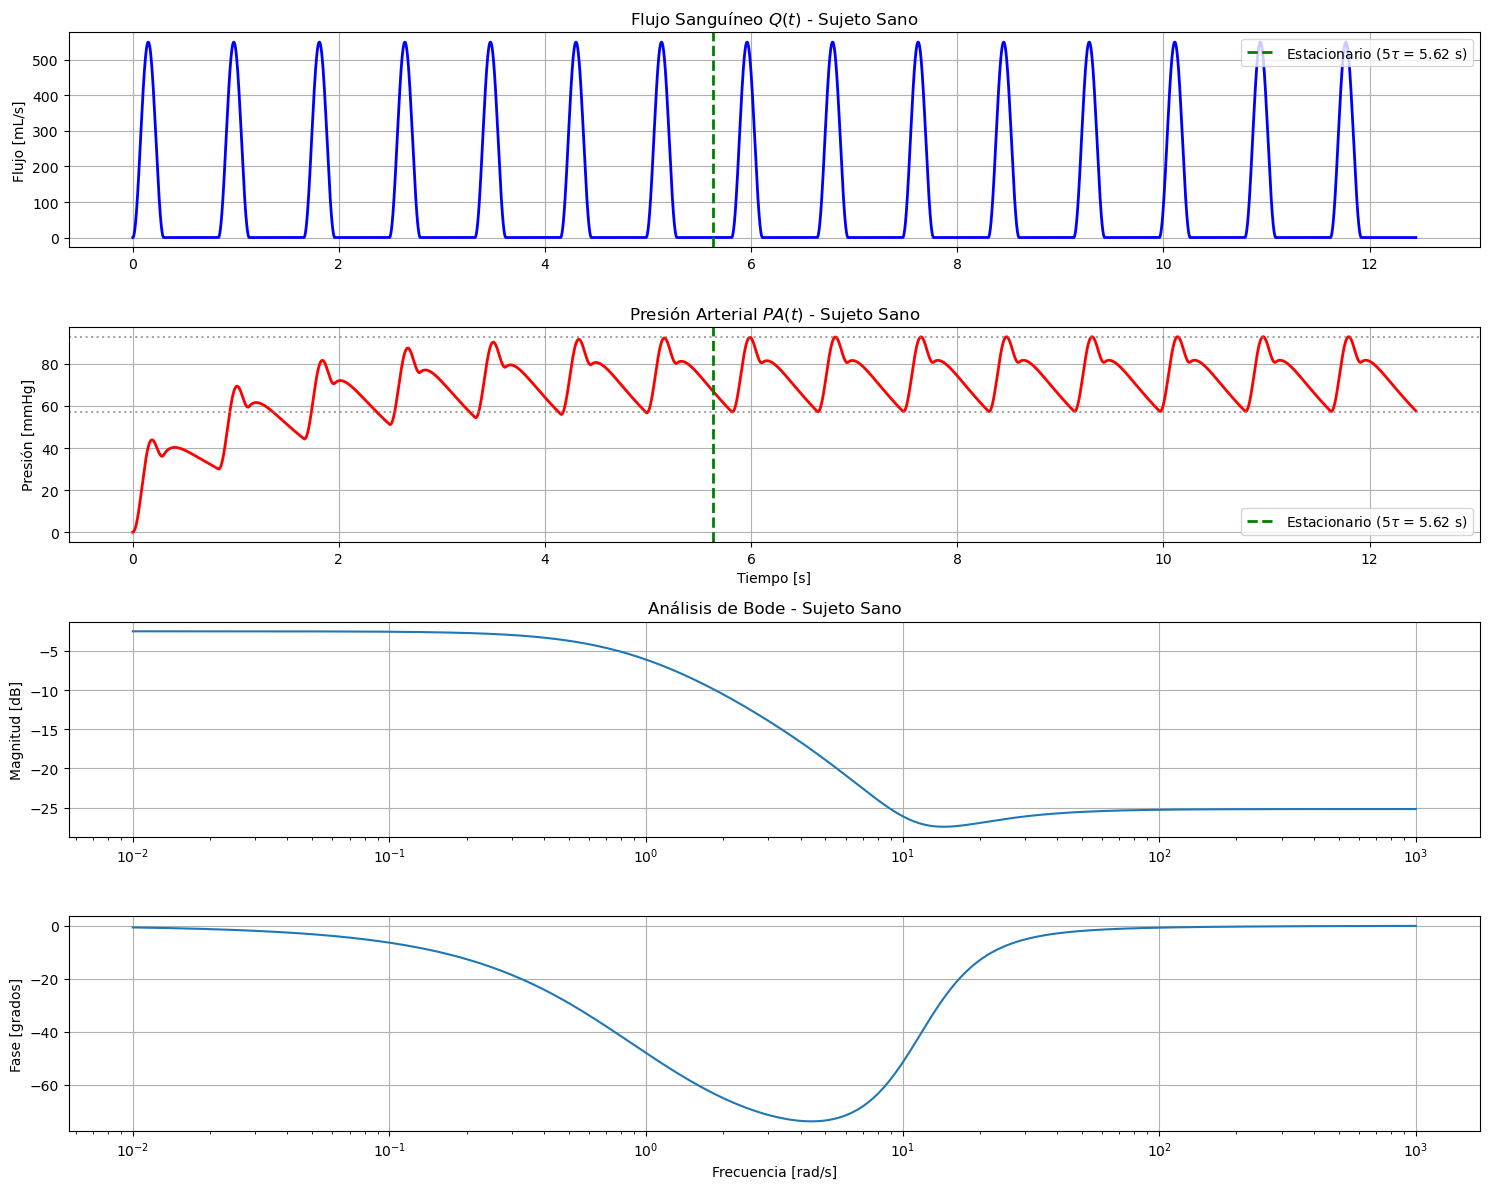

Simulando escenario W4: Hipertensión Severa...

--- Resultados para: Hipertensión Severa ---
Polos del sistema: [-23.       -0.78125]
Constante de tiempo (tau): 1.280 s
Tiempo de estabilización (5tau): 6.400 s
Presión Sistólica (Máx estacionaria):  215.9 mmHg
Presión Diastólica (Mín estacionaria): 159.4 mmHg


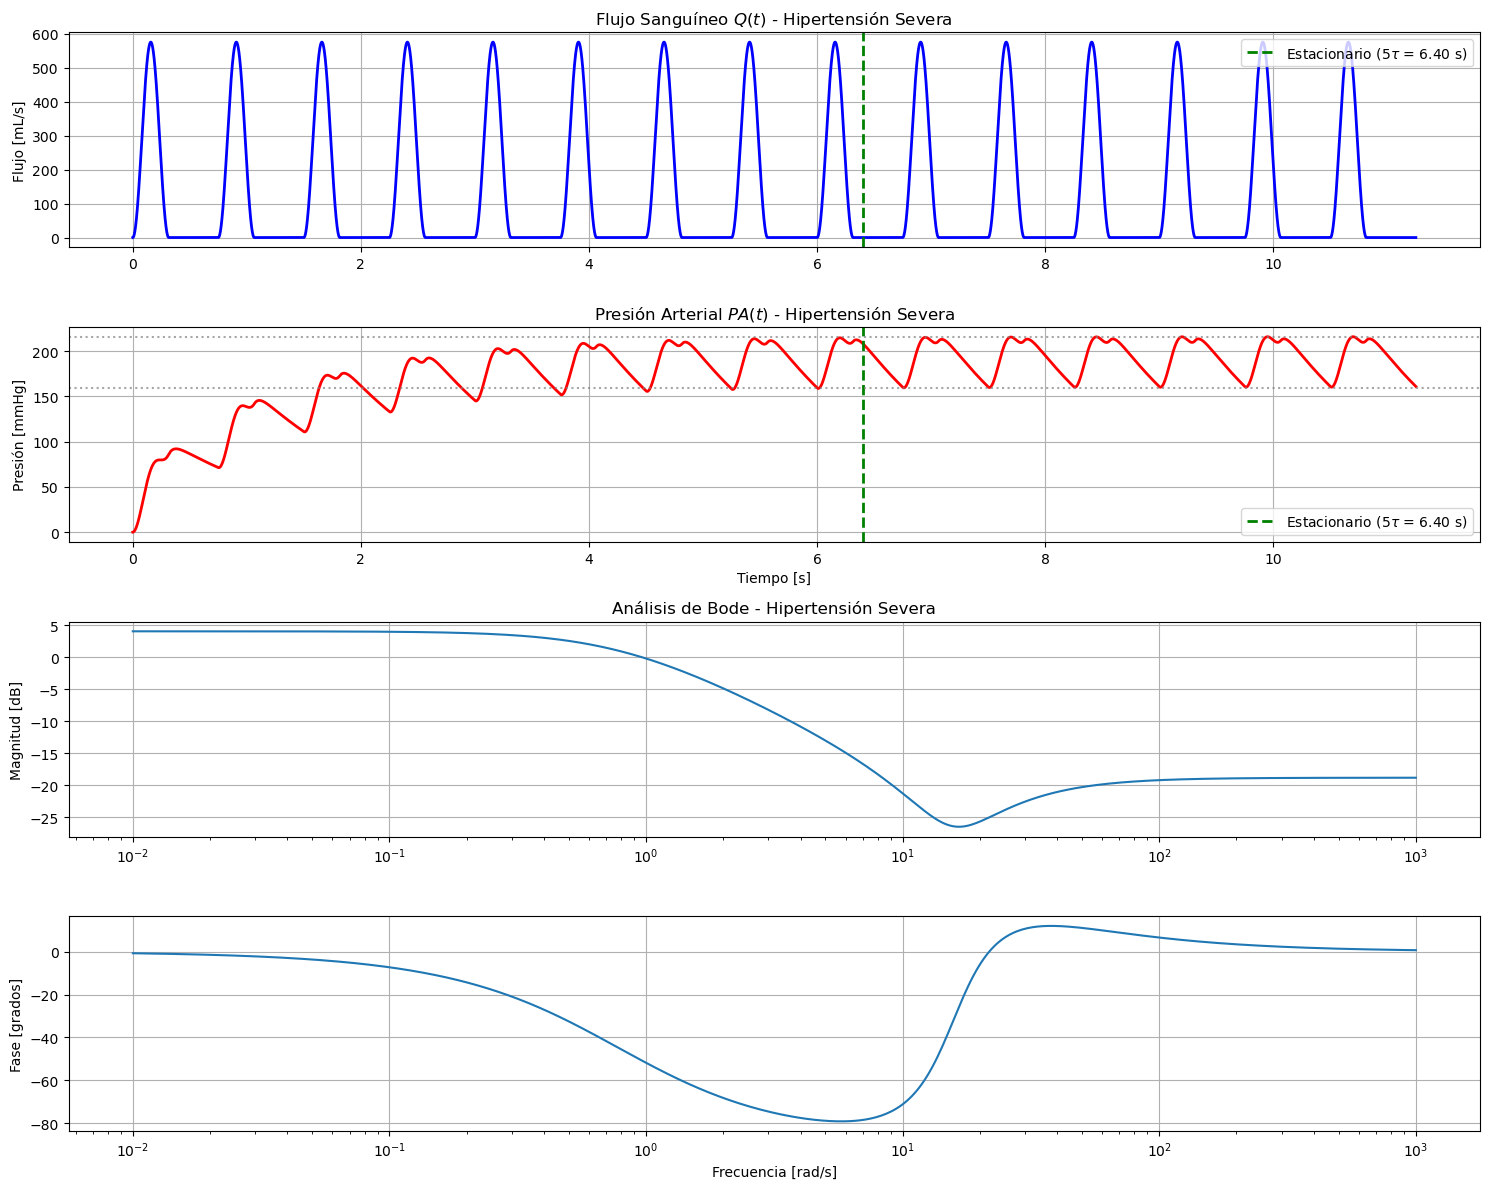

Simulando escenario W4: Arteriosclerosis...

--- Resultados para: Arteriosclerosis ---
Polos del sistema: [-35.55555556  -1.42857143]
Constante de tiempo (tau): 0.700 s
Tiempo de estabilización (5tau): 3.500 s
Presión Sistólica (Máx estacionaria):  118.6 mmHg
Presión Diastólica (Mín estacionaria): 61.0 mmHg


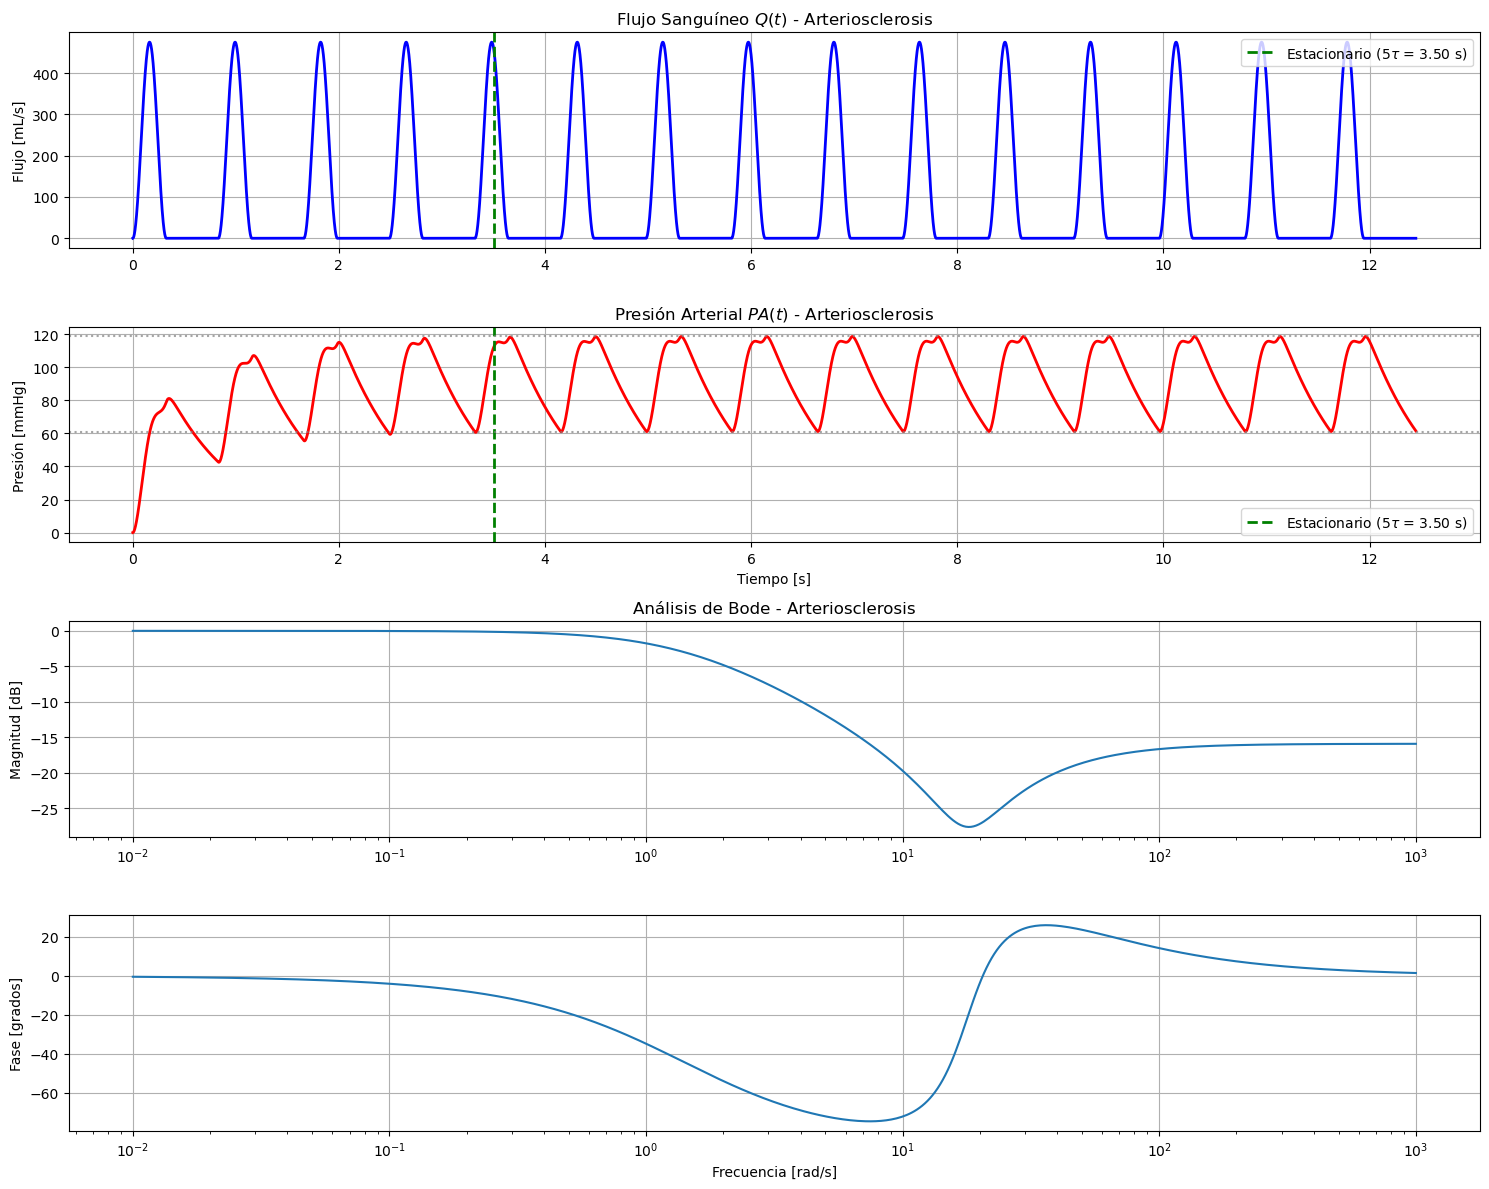

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. Matriz de Parámetros (Diccionario estructurado) ---
escenarios = {
    'Sujeto Sano': {
        'Rc': 0.055, 'Rp': 0.75, 'C': 1.5, 'L': 0.005, 
        'Q_max': 550.0, 'Ts': 0.300, 'Td': 0.530
    },
    'Hipertensión Severa': {
        'Rc': 0.115, 'Rp': 1.6, 'C': 0.8, 'L': 0.005, 
        'Q_max': 575.0, 'Ts': 0.315, 'Td': 0.435
    },
    'Arteriosclerosis': {
        'Rc': 0.160, 'Rp': 1.00, 'C': 0.70, 'L': 0.0045, 
        'Q_max': 475.0, 'Ts': 0.325, 'Td': 0.505
    }
}

# --- 2. Función Estandarizada ---
def simular_y_graficar_w4(nombre, params, num_ciclos=15, fs=1000):
    # Extraer parámetros del diccionario
    Rc, Rp, C, L = params['Rc'], params['Rp'], params['C'], params['L']
    Q_max, Ts, Td = params['Q_max'], params['Ts'], params['Td']
    
    T = Ts + Td  # Periodo total
    time = np.arange(0, num_ciclos * T, 1/fs)
    
    # Construcción de la Función de Transferencia H(s)
    numerador = [(Rc*Rp*L*C), (Rc*L + Rp*L), (Rc*Rp)]
    denominador = [(Rp*L*C), (Rc*Rp*C + L), Rc]
    sys_tf = signal.TransferFunction(numerador, denominador)
    
    # Cálculo del estado estacionario (5 tau)
    polos = np.roots(denominador)
    tau = 1 / np.min(np.abs(np.real(polos)))
    t_5tau = 5 * tau
    
    # Generación de la señal Q(t)
    t_cycle = time % T
    Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)
    
    # Simulación de la Presión Arterial
    t_out, PA, _ = signal.lsim(sys_tf, Q, T=time)
    
    # --- NUEVO: Cálculo de Presión Sistólica y Diastólica ---
    # Filtrar la presión aislando solo la región del estado estacionario
    PA_estacionaria = PA[time >= t_5tau]
    
    P_sistolica = np.max(PA_estacionaria)
    P_diastolica = np.min(PA_estacionaria)
    
    print(f"\n--- Resultados para: {nombre} ---")
    print(f"Polos del sistema: {polos}")
    print(f"Constante de tiempo (tau): {tau:.3f} s")
    print(f"Tiempo de estabilización (5tau): {t_5tau:.3f} s")
    print(f"Presión Sistólica (Máx estacionaria):  {P_sistolica:.1f} mmHg")
    print(f"Presión Diastólica (Mín estacionaria): {P_diastolica:.1f} mmHg")
    
    # --- Visualización ---
    plt.figure(figsize=(15, 12))
    
    # 1. Flujo de entrada
    plt.subplot(4, 1, 1)
    plt.plot(time, Q, color='blue', linewidth=2)
    plt.axvline(x=t_5tau, color='green', linestyle='--', linewidth=2, label=f'Estacionario ($5\\tau$ = {t_5tau:.2f} s)')
    plt.title(f'Flujo Sanguíneo $Q(t)$ - {nombre}')
    plt.ylabel('Flujo [mL/s]')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    # 2. Presión de salida
    plt.subplot(4, 1, 2)
    plt.plot(t_out, PA, color='red', linewidth=2)
    plt.axvline(x=t_5tau, color='green', linestyle='--', linewidth=2, label=f'Estacionario ($5\\tau$ = {t_5tau:.2f} s)')
    # Agregamos líneas horizontales para visualizar Sistólica y Diastólica
    plt.axhline(y=P_sistolica, color='gray', linestyle=':', alpha=0.7)
    plt.axhline(y=P_diastolica, color='gray', linestyle=':', alpha=0.7)
    plt.title(f'Presión Arterial $PA(t)$ - {nombre}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Presión [mmHg]')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    # 3. y 4. Análisis de Bode
    w = np.logspace(-2, 3, 500)       
    w, mag, phase = signal.bode(sys_tf, w=w)
    
    plt.subplot(4, 1, 3)
    plt.semilogx(w, mag)
    plt.title(f'Análisis de Bode - {nombre}')
    plt.ylabel('Magnitud [dB]')
    plt.grid(True)
    
    plt.subplot(4, 1, 4)
    plt.semilogx(w, phase)
    plt.xlabel('Frecuencia [rad/s]')
    plt.ylabel('Fase [grados]')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# --- 3. Ejecución iterativa para todos los casos ---
for nombre, parametros in escenarios.items():
    print(f"Simulando escenario W4: {nombre}...")
    simular_y_graficar_w4(nombre, parametros, num_ciclos=15)

### Deducción de la Función de Transferencia del Modelo W3

En la analogía fluídico-eléctrica, la presión arterial $PA(s)$ equivale al voltaje y el flujo sanguíneo $Q(s)$ equivale a la corriente. Por lo tanto, la función de transferencia $H(s) = \frac{PA(s)}{Q(s)}$ es exactamente la **impedancia equivalente** total del circuito en el dominio de Laplace.

**1. Definición de impedancias individuales**
Cada componente del circuito de la imagen se representa en el dominio de Laplace ($s$) con su respectiva impedancia:
*   Resistencia característica: $Z_{Rc}(s) = R_c$
*   Resistencia periférica: $Z_{Rp}(s) = R_p$
*   Compliancia (Capacitor): $Z_C(s) = \frac{1}{sC}$

**2. Cálculo del bloque en paralelo**
El capacitor $C$ y la resistencia $R_p$ están conectados en paralelo. La impedancia equivalente de este bloque ($Z_p$) se calcula como el producto sobre la suma:

$$Z_p(s) = \frac{Z_{Rp}(s) \cdot Z_C(s)}{Z_{Rp}(s) + Z_C(s)}$$

$$Z_p(s) = \frac{R_p \cdot \frac{1}{sC}}{R_p + \frac{1}{sC}}$$

$$Z_p(s) = \frac{R_p}{sCR_p + 1}$$

**3. Impedancia total (Función de Transferencia $H(s)$)**
La resistencia $R_c$ está en serie con el bloque paralelo $Z_p$:

$$H(s) = Z_{Rc}(s) + Z_p(s)$$

$$H(s) = R_c + \frac{R_p}{sCR_p + 1}$$

$$H(s) = \frac{R_c(sCR_p + 1) + R_p}{sCR_p + 1}$$

$$H(s) = \frac{sCR_c R_p + R_c + R_p}{sCR_p + 1}$$

$$H(s) = \frac{(R_c R_p C)s + (R_c + R_p)}{(R_p C)s + 1}$$

---

Simulando escenario W3: Sujeto Sano...

--- Resultados para: Sujeto Sano (Modelo W3) ---
Los polos del sistema son: [-0.88888889]
Constante de tiempo dominante (tau): 1.125 s
Tiempo de estabilización (5tau): 5.625 s
Presión Sistólica (Máx estacionaria):  113.0 mmHg
Presión Diastólica (Mín estacionaria): 57.1 mmHg
Simulando escenario W3: Hipertensión Severa...

--- Resultados para: Hipertensión Severa (Modelo W3) ---
Los polos del sistema son: [-0.78125]
Constante de tiempo dominante (tau): 1.280 s
Tiempo de estabilización (5tau): 6.400 s
Presión Sistólica (Máx estacionaria):  273.7 mmHg
Presión Diastólica (Mín estacionaria): 159.5 mmHg
Simulando escenario W3: Arteriosclerosis...

--- Resultados para: Arteriosclerosis (Modelo W3) ---
Los polos del sistema son: [-1.42857143]
Constante de tiempo dominante (tau): 0.700 s
Tiempo de estabilización (5tau): 3.500 s
Presión Sistólica (Máx estacionaria):  185.2 mmHg
Presión Diastólica (Mín estacionaria): 61.0 mmHg


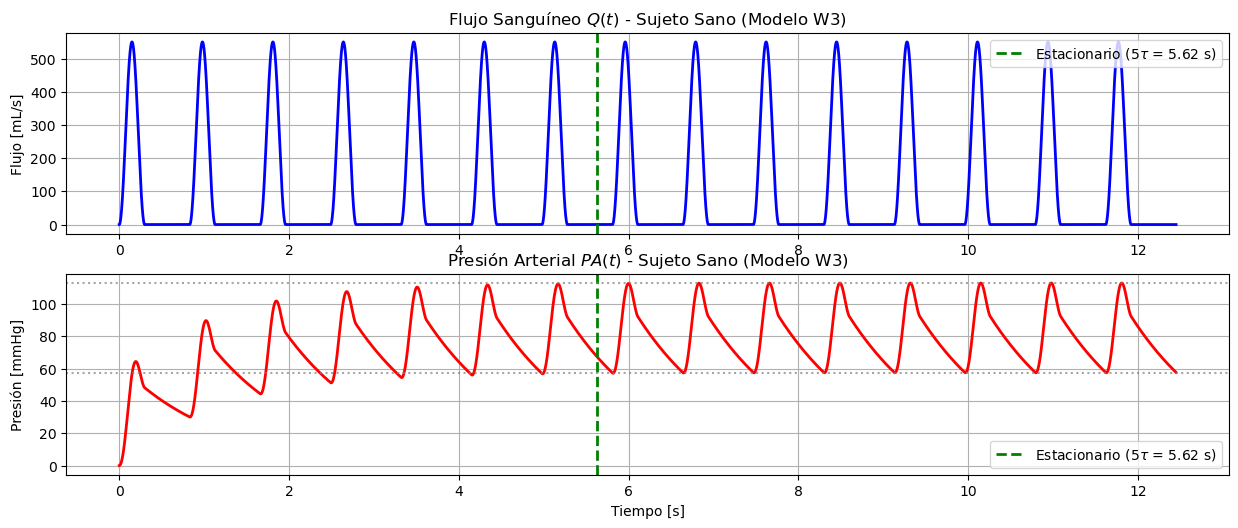

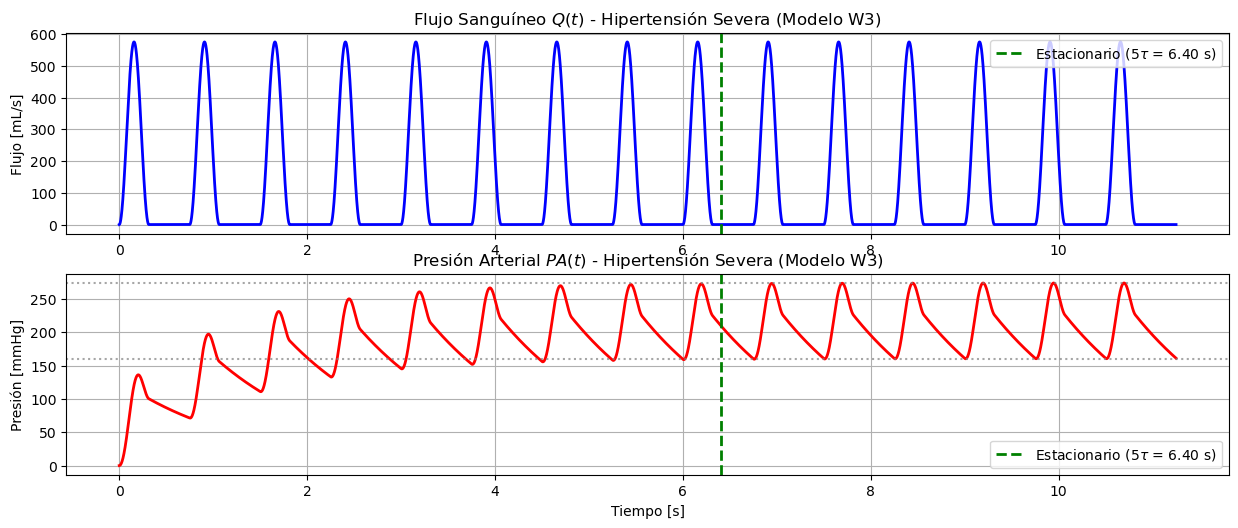

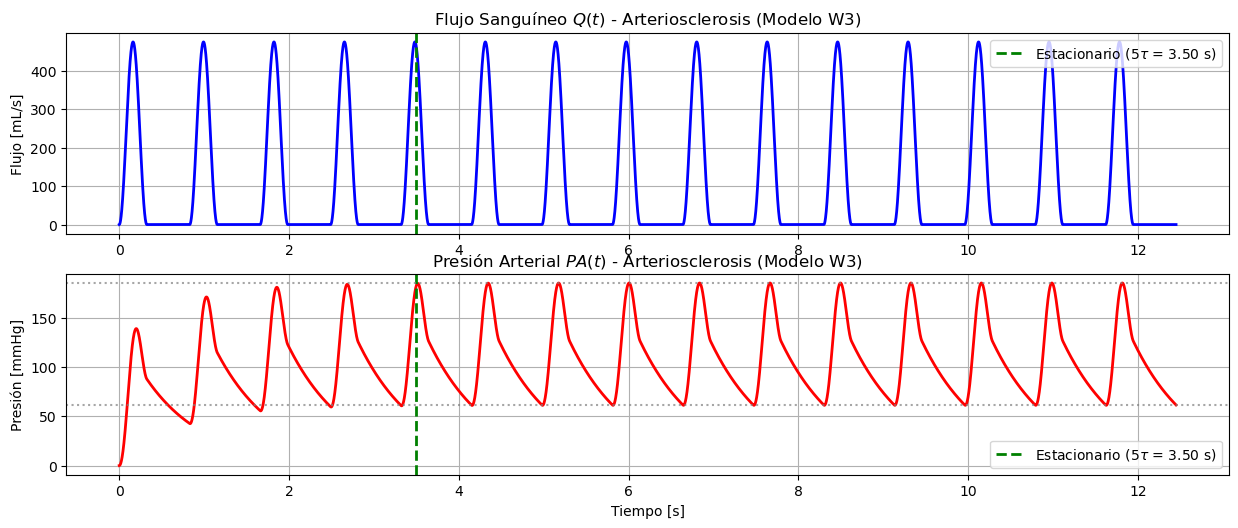

In [19]:
# --- 2. Función Estandarizada para el Modelo W3 ---
def simular_y_graficar_w3(nombre, params, num_ciclos=15, fs=1000):
    # Extraer parámetros del diccionario (Omitimos 'L' ya que el modelo W3 no lo usa)
    Rc, Rp, C = params['Rc'], params['Rp'], params['C']
    Q_max, Ts, Td = params['Q_max'], params['Ts'], params['Td']
    
    T = Ts + Td  # Periodo total
    time = np.arange(0, num_ciclos * T, 1/fs)
    
    # Construcción de la Función de Transferencia H(s) para W3
    numerador = [(Rc * Rp * C), (Rc + Rp)]
    denominador = [(Rp * C), 1]
    sys_tf = signal.TransferFunction(numerador, denominador)
    
    # Cálculo del estado estacionario (5 tau)
    polos = np.roots(denominador)
    tau = 1 / np.min(np.abs(np.real(polos)))
    t_5tau = 5 * tau

    # Generación de la señal Q(t)
    t_cycle = time % T
    Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)
    
    # Simulación de la Presión Arterial
    t_out, PA, _ = signal.lsim(sys_tf, Q, T=time)
    
    # --- NUEVO: Cálculo de Presión Sistólica y Diastólica ---
    # Filtrar la presión aislando solo la región del estado estacionario
    PA_estacionaria = PA[time >= t_5tau]
    
    P_sistolica = np.max(PA_estacionaria)
    P_diastolica = np.min(PA_estacionaria)
    
    print(f"\n--- Resultados para: {nombre} (Modelo W3) ---")
    print(f"Los polos del sistema son: {polos}")
    print(f"Constante de tiempo dominante (tau): {tau:.3f} s")
    print(f"Tiempo de estabilización (5tau): {t_5tau:.3f} s")
    print(f"Presión Sistólica (Máx estacionaria):  {P_sistolica:.1f} mmHg")
    print(f"Presión Diastólica (Mín estacionaria): {P_diastolica:.1f} mmHg")
    
    # --- Visualización ---
    plt.figure(figsize=(15, 12))
    
    # 1. Flujo de entrada
    plt.subplot(4, 1, 1)
    plt.plot(time, Q, color='blue', linewidth=2)
    plt.axvline(x=t_5tau, color='green', linestyle='--', linewidth=2, label=f'Estacionario ($5\\tau$ = {t_5tau:.2f} s)')
    plt.title(f'Flujo Sanguíneo $Q(t)$ - {nombre} (Modelo W3)')
    plt.ylabel('Flujo [mL/s]')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    # 2. Presión de salida
    plt.subplot(4, 1, 2)
    plt.plot(t_out, PA, color='red', linewidth=2)
    plt.axvline(x=t_5tau, color='green', linestyle='--', linewidth=2, label=f'Estacionario ($5\\tau$ = {t_5tau:.2f} s)')
    # Líneas de referencia para las presiones
    plt.axhline(y=P_sistolica, color='gray', linestyle=':', alpha=0.7)
    plt.axhline(y=P_diastolica, color='gray', linestyle=':', alpha=0.7)
    plt.title(f'Presión Arterial $PA(t)$ - {nombre} (Modelo W3)')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Presión [mmHg]')
    plt.legend(loc='lower right')
    plt.grid(True)
    
  

# --- 3. Ejecución iterativa para todos los casos ---
for nombre, parametros in escenarios.items():
    print(f"Simulando escenario W3: {nombre}...")
    simular_y_graficar_w3(nombre, parametros, num_ciclos=15)